In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
counts_path = Path(analysis_directory.name) / "counts.zarr"
analysis_path = Path(analysis_directory.name) / "downsampling.zarr"
repack_store(f"{dataset}/data.zarr", str(counts_path), nthreads=2)
ds = scarf.mount_datastore(
    str(counts_path),
    at=str(analysis_path),
    default_assay="RNA",
    nthreads=4,
)

preparation = ds.pipeline.run(
    filtering=False,
    hvg_count=500,
    pca_dims=15,
    neighbors_k=11,
    umap=True,
    leiden=False,
    cell_cycle=False,
    paris=True,
    doublets=False,
    markers=False,
)
graph = preparation["connectivity_map"]
umap = preparation["umap"]
paris = preparation["paris"]

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

...

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Training UMAP: 300 / 300 complete

In [2]:
paris_result = ds.load_paris_clustering(paris)
pd.Series(paris_result.labels).value_counts().sort_index()

1      337
2      385
3      257
4     1269
5      317
6      558
7      137
8      243
9      410
10      15
11      12
Name: count, dtype: int64

In [3]:
sampling = ds.run_topacedo_sampler(
    graph,
    paris,
    max_sampling_rate=0.1,
)
sampling_data = ds.load_artifact(sampling)
sampled = np.asarray(sampling_data["sampled"][:], dtype=bool)
seeds = np.asarray(sampling_data["seeds"][:], dtype=bool)
density = np.asarray(sampling_data["density"][:])
mean_snn = np.asarray(sampling_data["mean_snn"][:])
{
    "cells": int(sampled.size),
    "selected": int(sampled.sum()),
    "seeds": int(seeds.sum()),
}

Constructing graph from dendrogram: 3939 / 3939 complete

INFO: 341 cells (8.65%) sub-sampled. Subsample to Seed (148 cells) ratio: 2.304


{'cells': 3940, 'selected': 341, 'seeds': 148}

In [4]:
summary = pd.DataFrame(
    {
        "cluster": paris_result.labels,
        "sampled": sampled,
        "seed": seeds,
        "density": density,
        "mean_snn": mean_snn,
    }
)
summary.groupby("cluster", sort=True).agg(
    cells=("sampled", "size"),
    selected=("sampled", "sum"),
    seeds=("seed", "sum"),
    mean_density=("density", "mean"),
    mean_snn=("mean_snn", "mean"),
)

,cells,selected,seeds,mean_density,mean_snn
cluster,,,,,
1,337,27,11,1447.008491,3.663798
2,385,39,18,1327.895880,3.780779
3,257,21,9,1461.142364,3.980545
4,1269,71,25,1615.755988,2.631678
5,317,52,21,1273.936293,4.839432
6,558,54,27,1310.606043,3.802151
7,137,12,7,1319.430515,4.259854
8,243,16,7,1498.047238,3.856790
9,410,42,17,1372.410130,3.601220


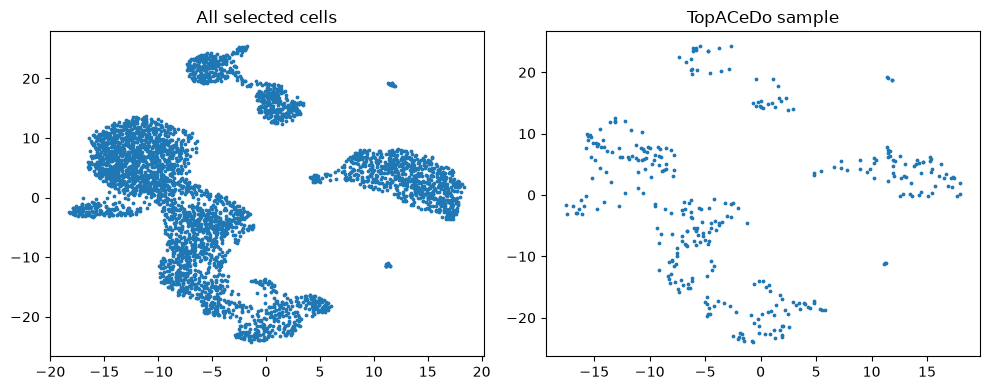

In [5]:
coordinates = np.asarray(ds.load_artifact(umap)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(coordinates[:, 0], coordinates[:, 1], s=3)
axes[0].set_title("All selected cells")
axes[1].scatter(coordinates[sampled, 0], coordinates[sampled, 1], s=3)
axes[1].set_title("TopACeDo sample")
figure.tight_layout()

In [6]:
ds.cells.insert(
    "topacedo_selected",
    sampled,
    key="I",
    fill_value=False,
    overwrite=True,
)

subset_path = Path(analysis_directory.name) / "subset.zarr"
writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_key="topacedo_selected",
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

subset = scarf.DataStore(str(subset_path))
subset.cells.N, subset.RNA.feats.N

Subsetting assay: RNA: 1 / 1 complete

Computing RNA initialization statistics: 1 / 1 complete

(341, 33538)